# Viz_V6 — Route A Result Visualization

Reads CSV + JSON from `results/<DATE_FOLDER>/` (produced by `train.py --route A`).
All figures are saved to the same date folder as PDF.
**Edit Cell 1 to set paths and style overrides.**

**V6.0 metrics:**
- **L1** — ExMatch, Macro ROC-AUC, Macro F1, per-EVCS ROC
- **L2** — L2-b delta-AUC (**PRIMARY**), L2-a IG, Aux attack-type accuracy
- **MIA** — reference only (downgraded in V6.0)
- **Efficiency** — wall-clock time, peak memory

In [49]:
# Cell 1 — Config (edit here)
# ============================================================
DATE_FOLDER = '2026-04-24_01'   # ← change to your results folder name
BUS_SYSTEM  = '123bus'            # '34bus' or '123bus'
TAG         = 'routeA'           # V6.0 Route A output tag

# Style overrides — passed to apply_style(); see src/visualization.py STYLE dict
STYLE_OVERRIDES = {
    # Font — Times New Roman for all text
    'font_family':   'Times New Roman',
    'fs_label':      26,
    'fs_tick':       20,
    'fs_legend':     20,
    'fs_subtitle':   22,
    'fs_annotation': 18,

    # Colors — 5 methods (Original, GDGU, GIF, IDEA, Retrain-A)
    'colors': {
        'Original':  "#C7CADE",
        'GDGU':      "#F7AC53",
        'GIF':       "#52AADC",
        'IDEA':      "#EC6E66",
        'Retrain':   "#76BC79",
        'Retrain-A': "#0AF612",
    },
    'markers': {
        'Original':  'o',
        'GDGU':      's',
        'GIF':       'D',
        'IDEA':      'P',
        'Retrain':   '^',
        'Retrain-A': '^',
    },
    'ideal_line_color': 'red',
    'grid_alpha':       0.3,
    'bar_alpha':        0.85,
    'bar_edge_color':   'black',
    'bar_edge_width':   0.5,
    'fill_alpha':       0.15,

    # Save
    'save_fmt': 'pdf',
    'save_dpi': 300,
}

In [50]:
# Cell 2 — Setup
import sys, json
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (apply_style, load_results, plot_all_v6,
                                plot_l2b_delta_auc, plot_aux_accuracy,
                                plot_l2_heatmap, plot_metric_bars,
                                plot_per_evcs_roc, plot_mia_auc,
                                plot_mia_forget, plot_mia_retain,
                                plot_gu_comparison, plot_time_comparison,
                                plot_memory_usage)

%load_ext autoreload
%autoreload 2

apply_style(STYLE_OVERRIDES)

RESULTS_DIR = PROJECT_ROOT / 'results' / DATE_FOLDER
df, scenarios, backbones = load_results(str(RESULTS_DIR), BUS_SYSTEM, tag=TAG)

# Show metadata from epoch logs if available
log_path = RESULTS_DIR / f'{BUS_SYSTEM}_{TAG}_epoch_logs.json'
if log_path.exists():
    with open(log_path) as f:
        meta = json.load(f).get('_metadata', {})
    print(f"\nTimestamp : {meta.get('timestamp', 'N/A')}")
    print(f"Device   : {meta.get('device', 'N/A')}")
    d = meta.get('data', {})
    print(f"Graphs={d.get('n_graphs')}, Nodes={d.get('n_nodes')}, "
          f"Features={d.get('n_feat')}, EVCS={d.get('n_evcs')}")
    for name, n_params in meta.get('model_params', {}).items():
        print(f"  {name}: {n_params:,} params")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 750 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-24_01/123bus_routeA_results_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1', 'S2', 'S3', 'S4', 'S5']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']

Timestamp : 2026-04-24 11:26:36
Device   : cuda:1
Graphs=4000, Nodes=132, Features=48, EVCS=5
  GAT: 391,557 params
  GCN: 73,605 params
  GIN: 123,141 params


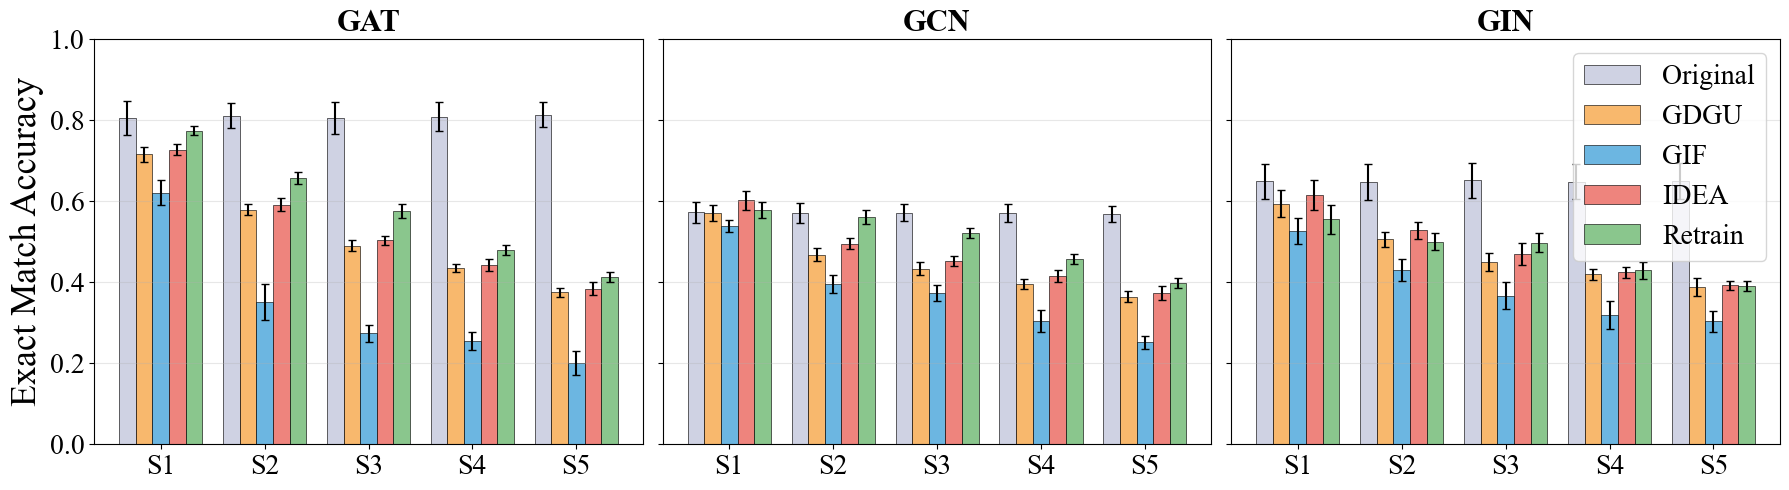

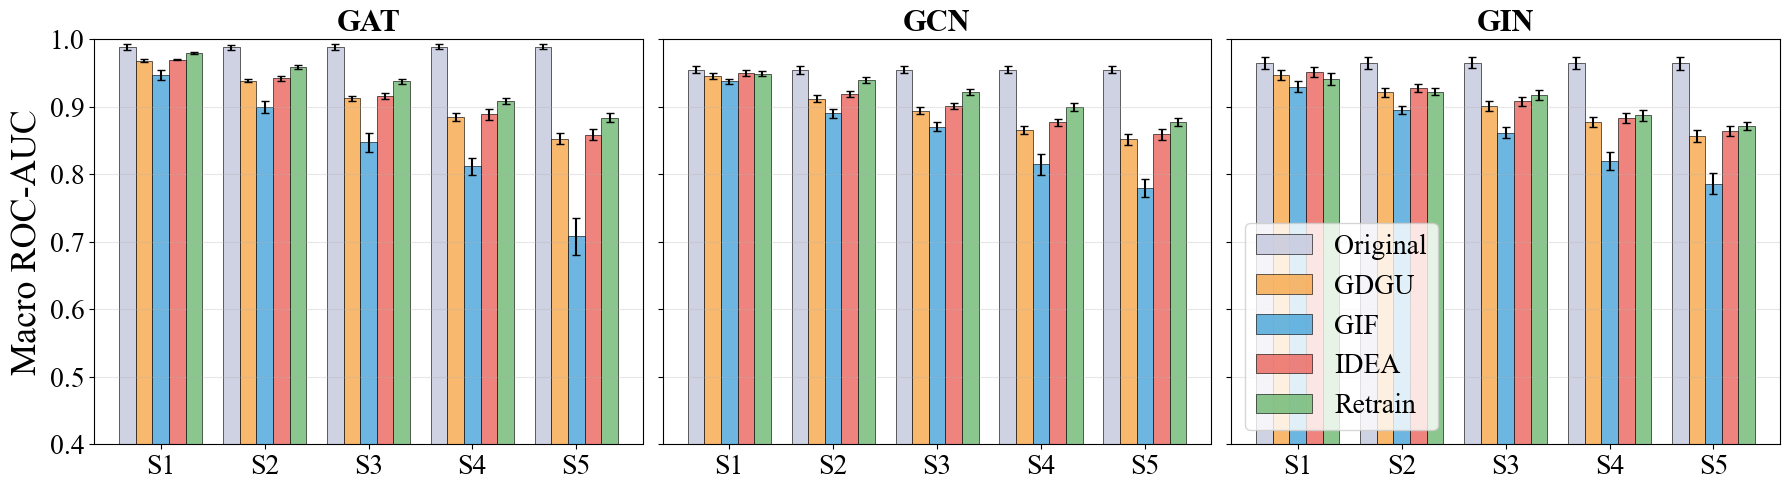

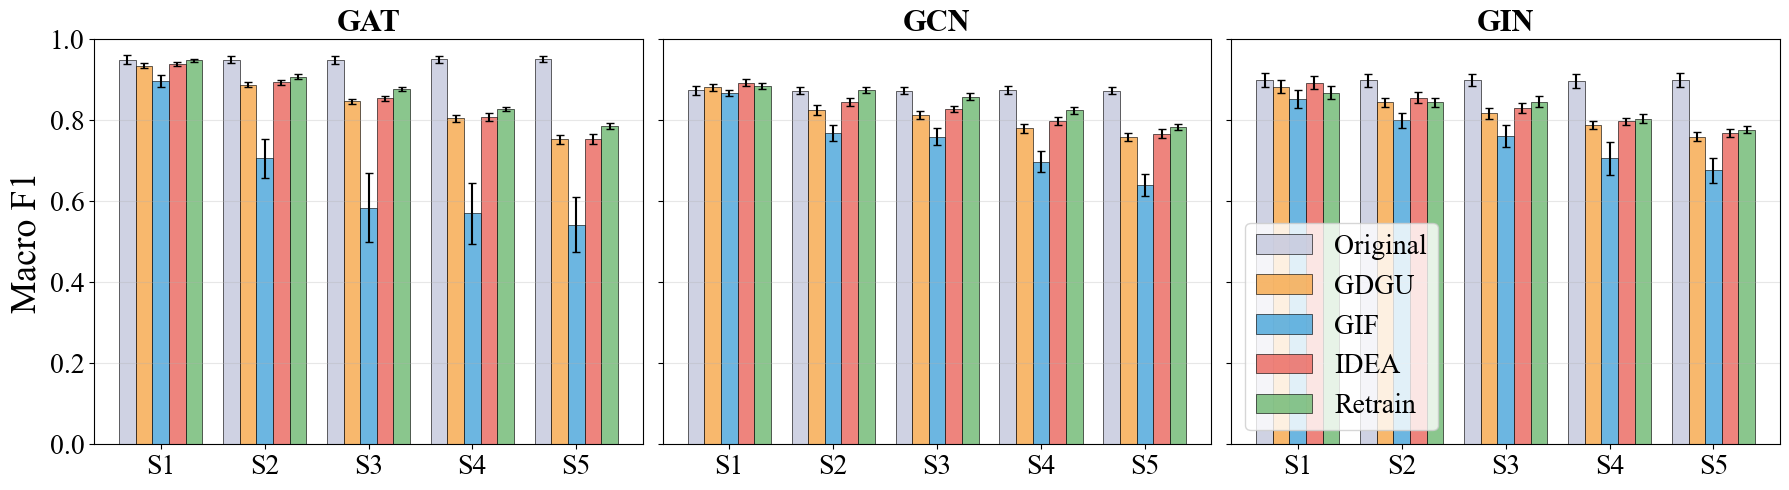

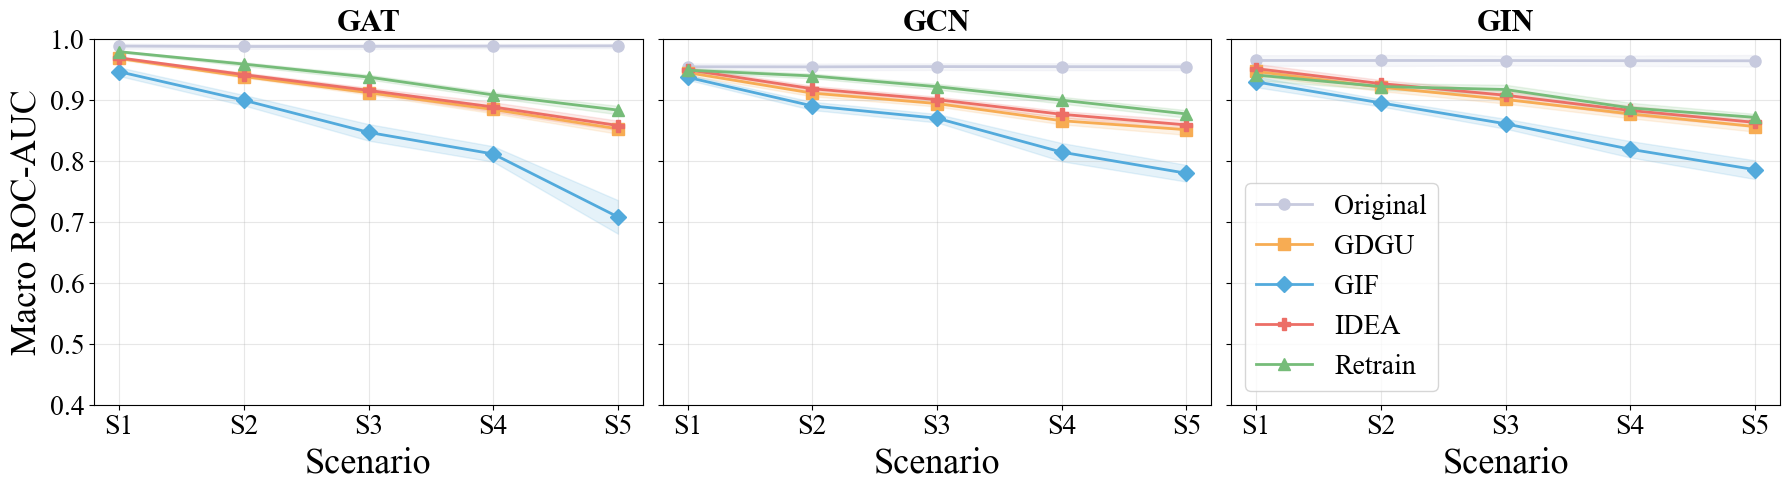

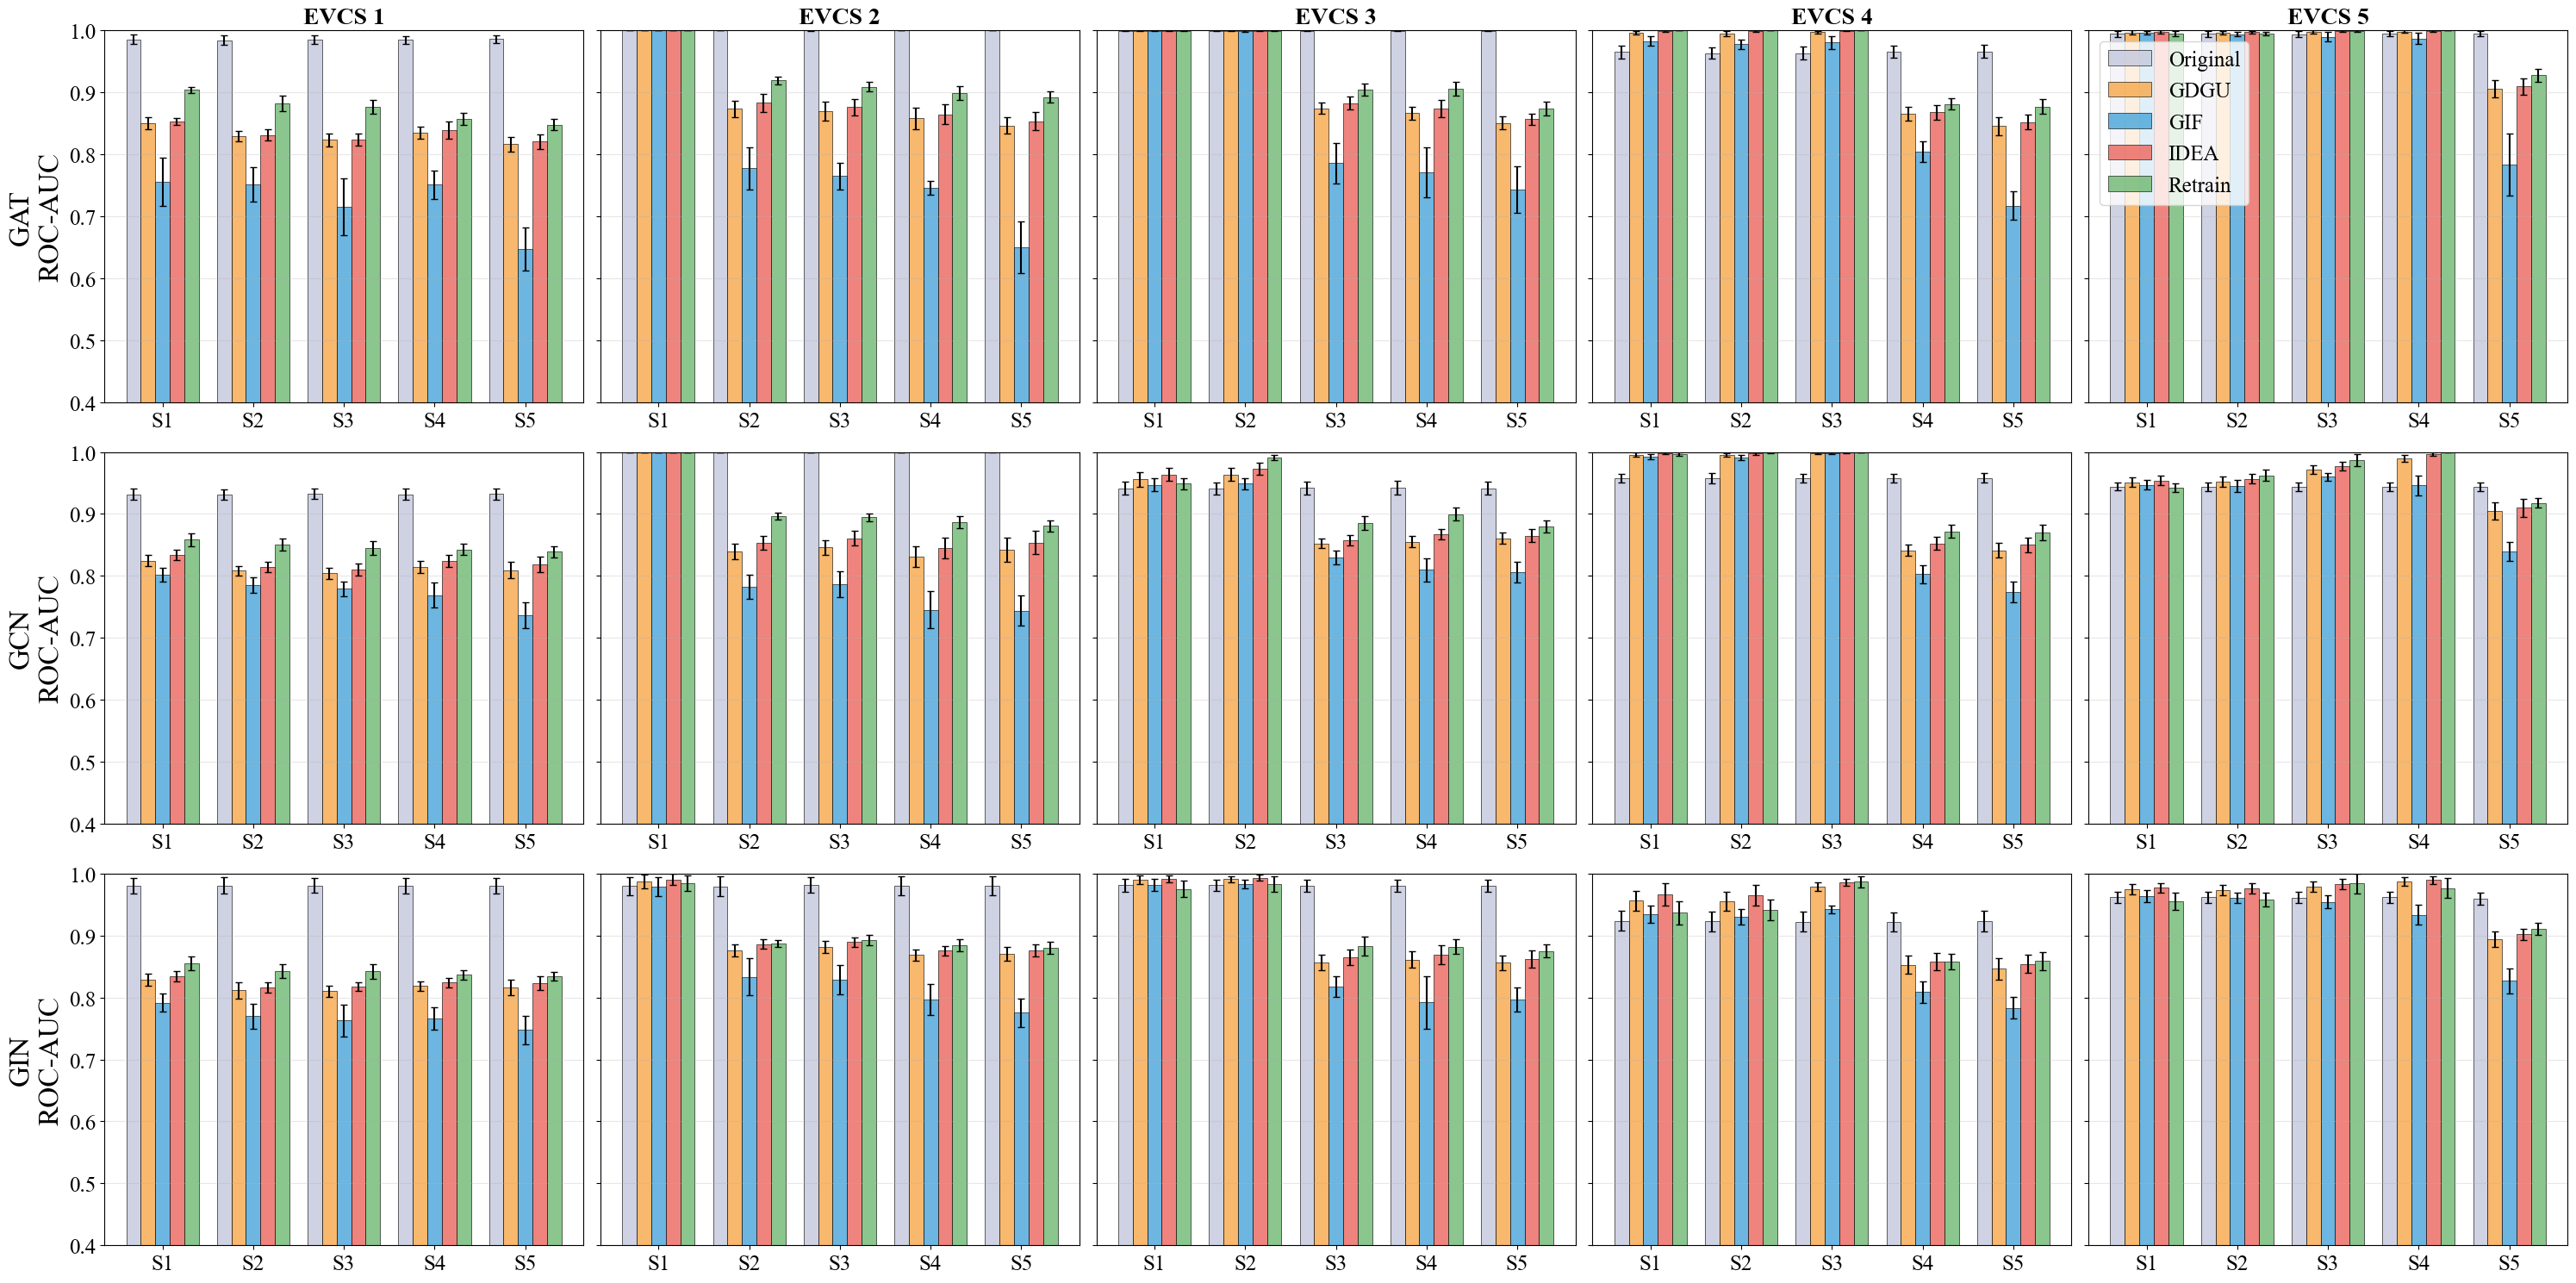

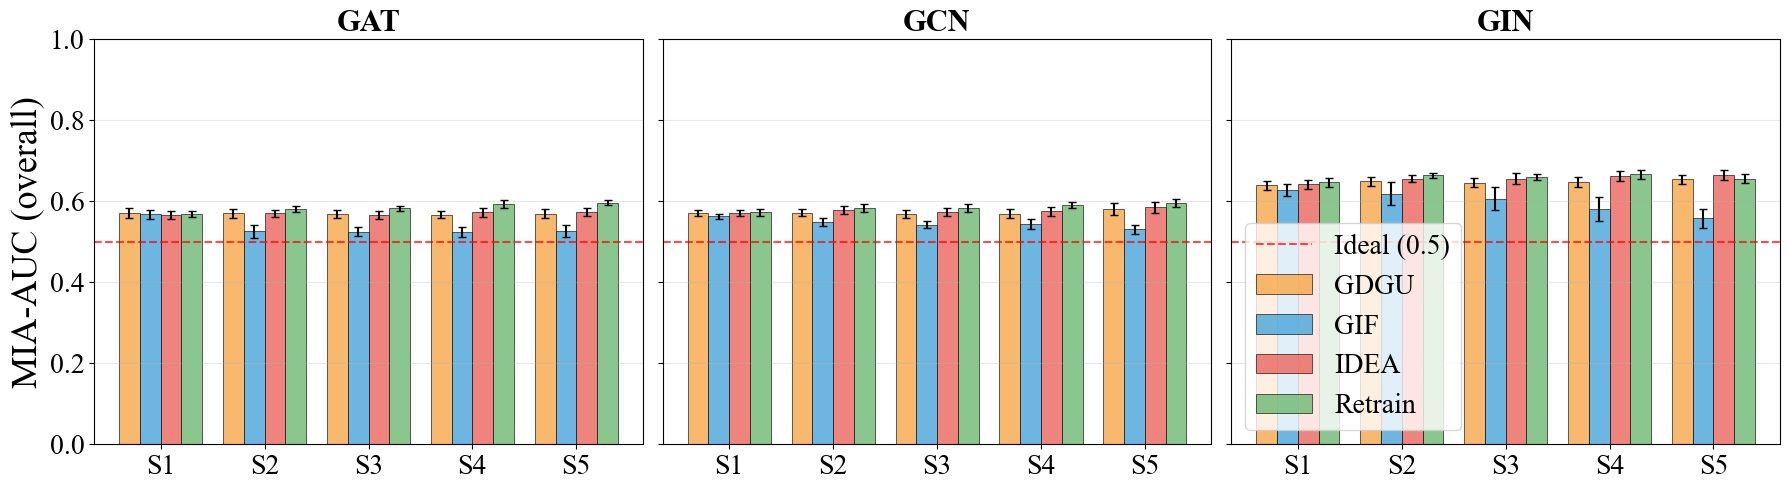

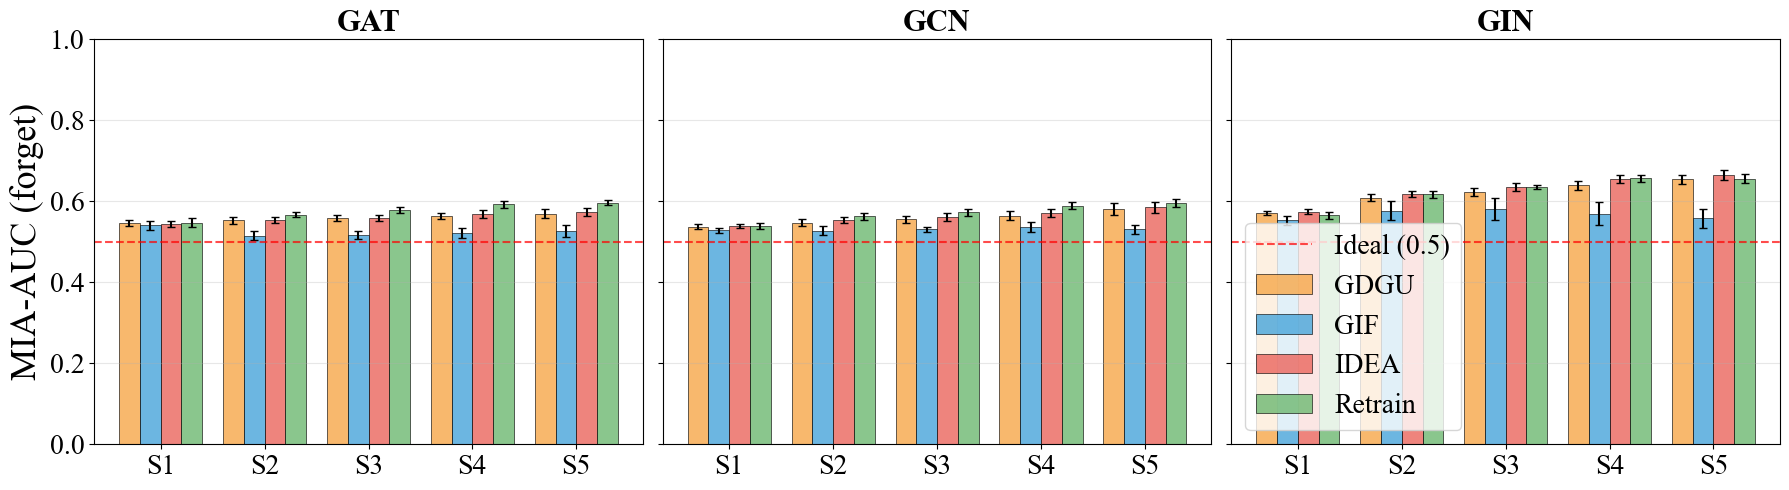

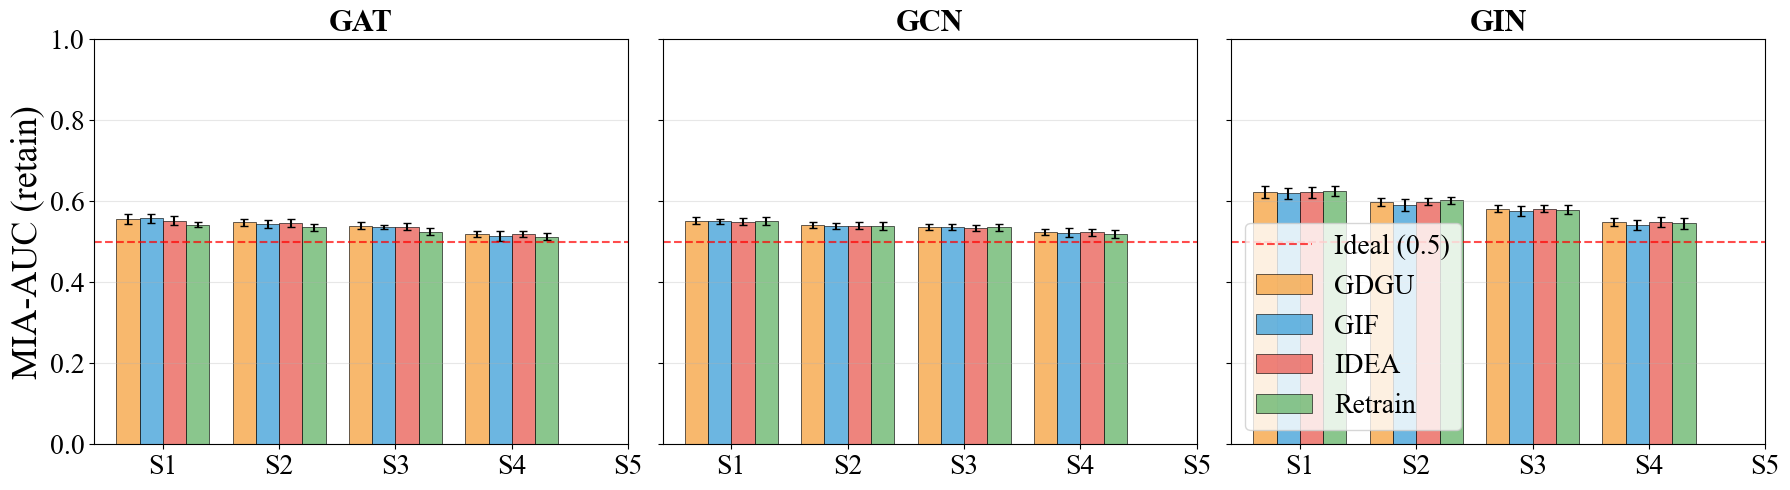

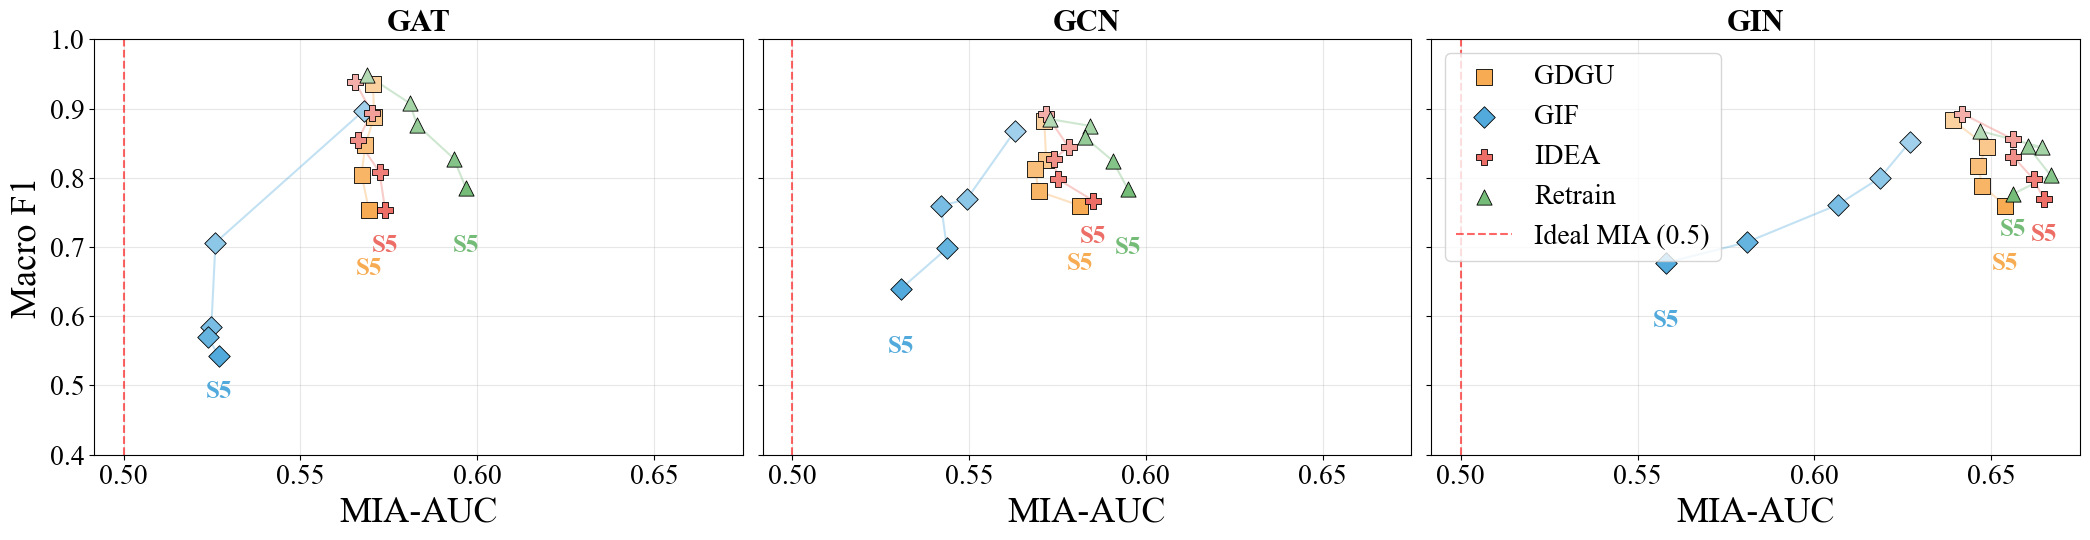

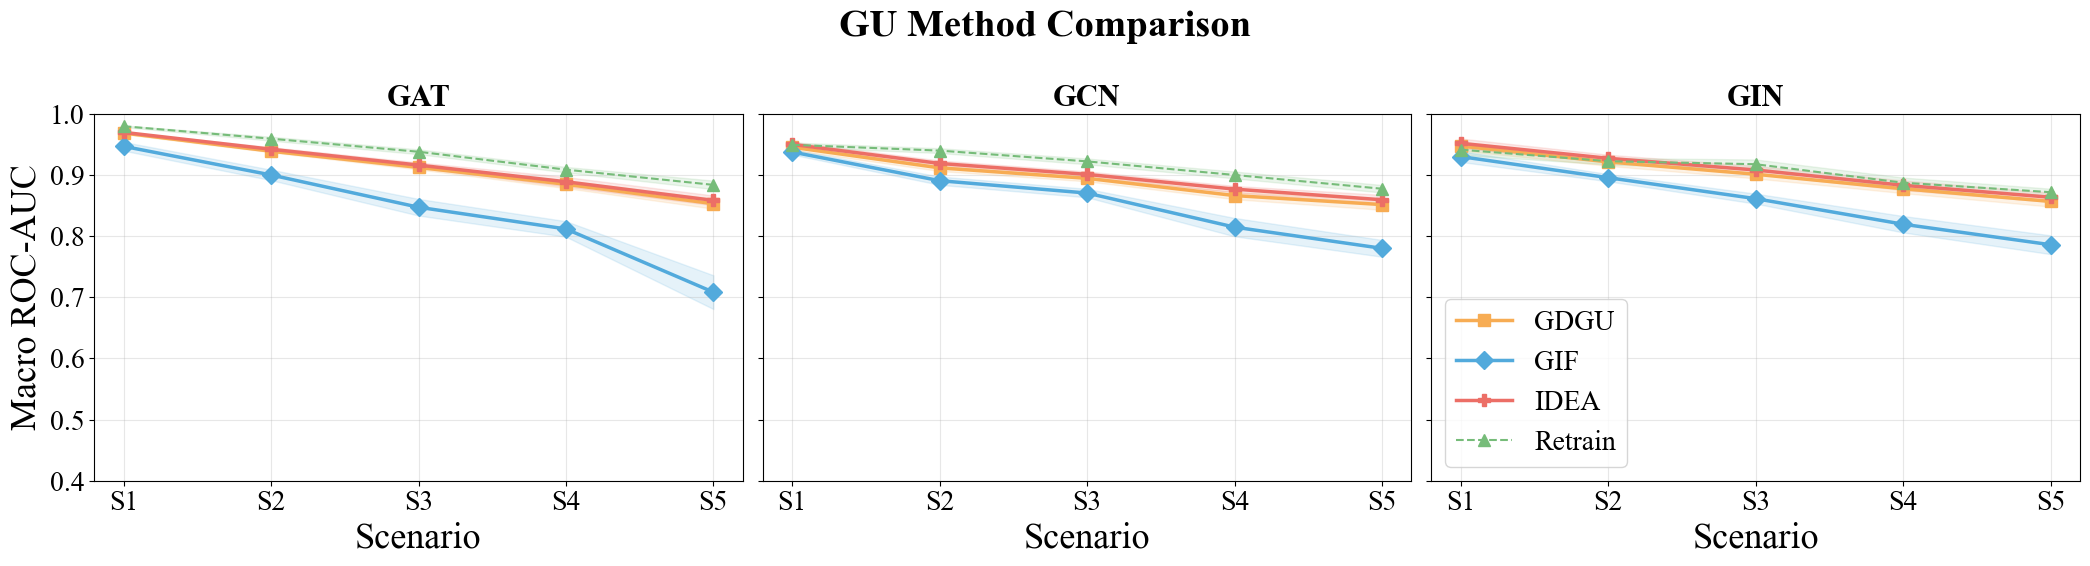

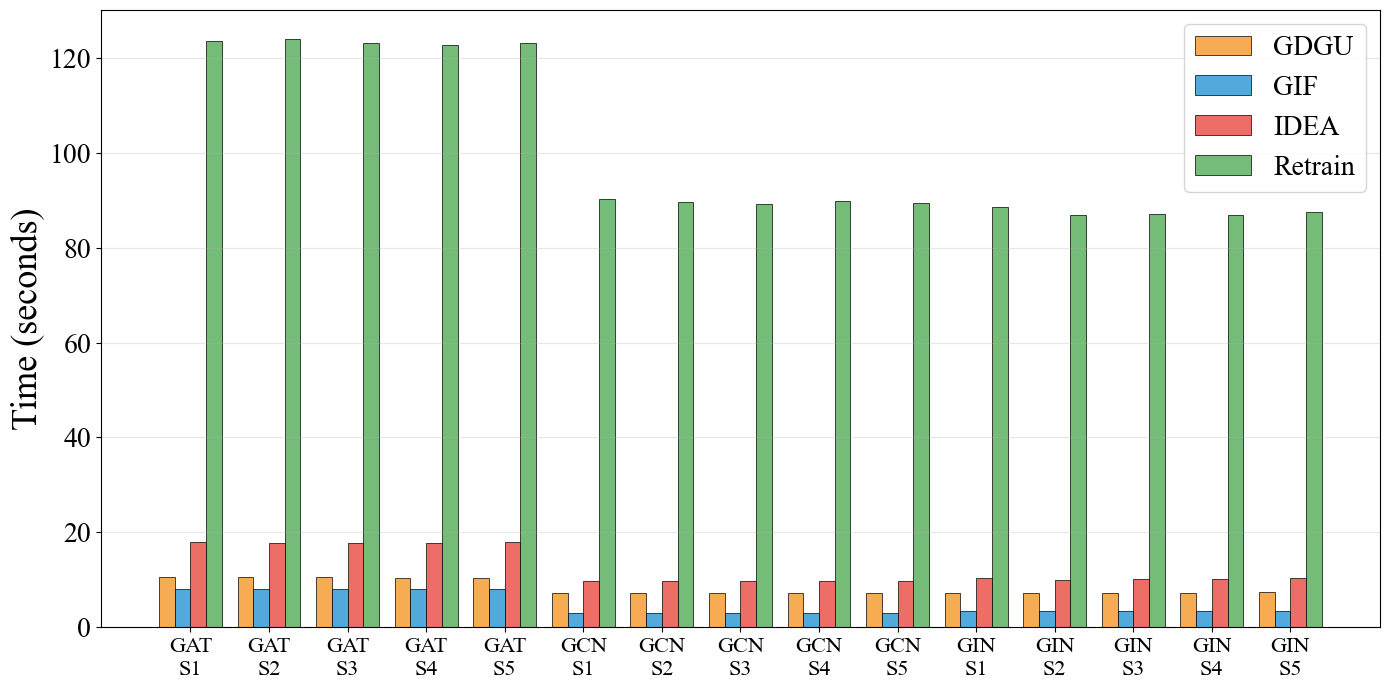

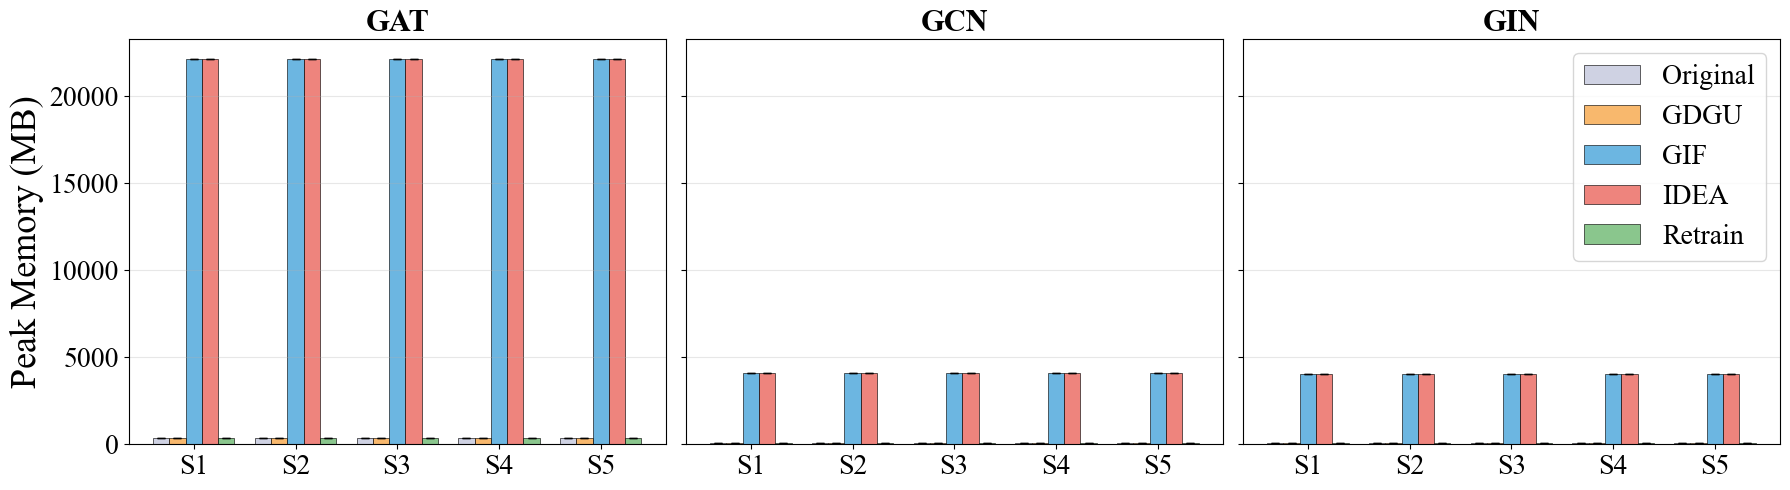

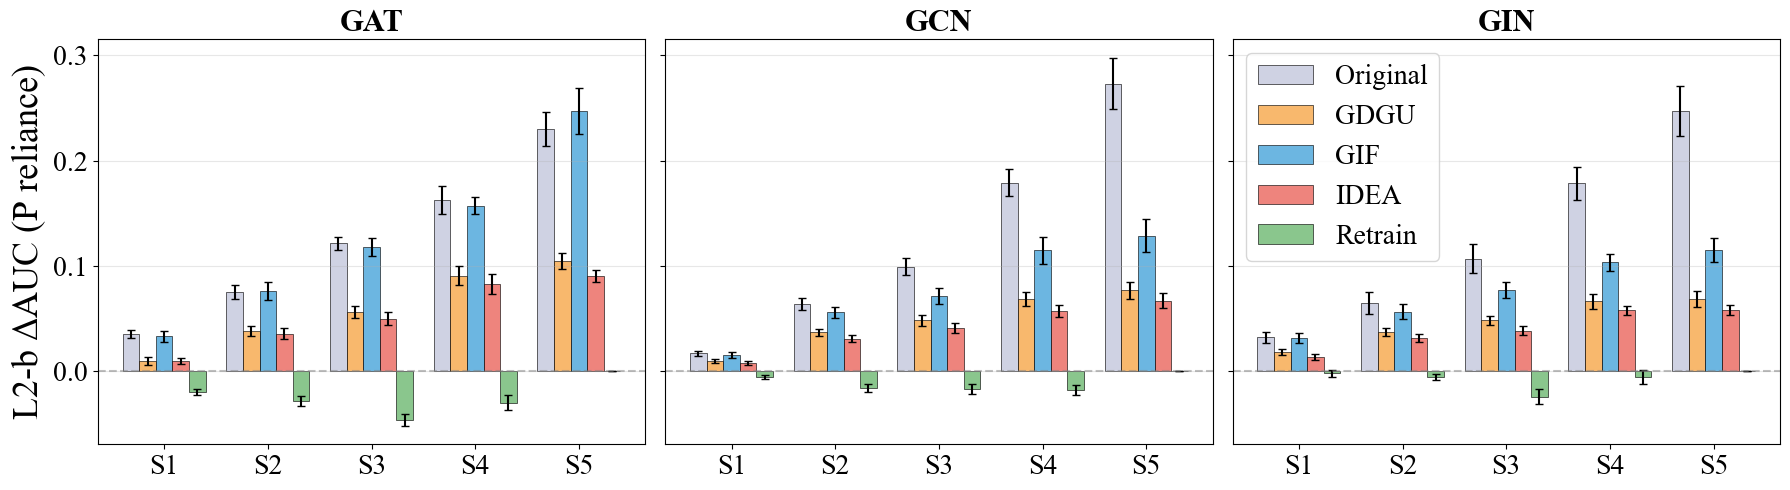

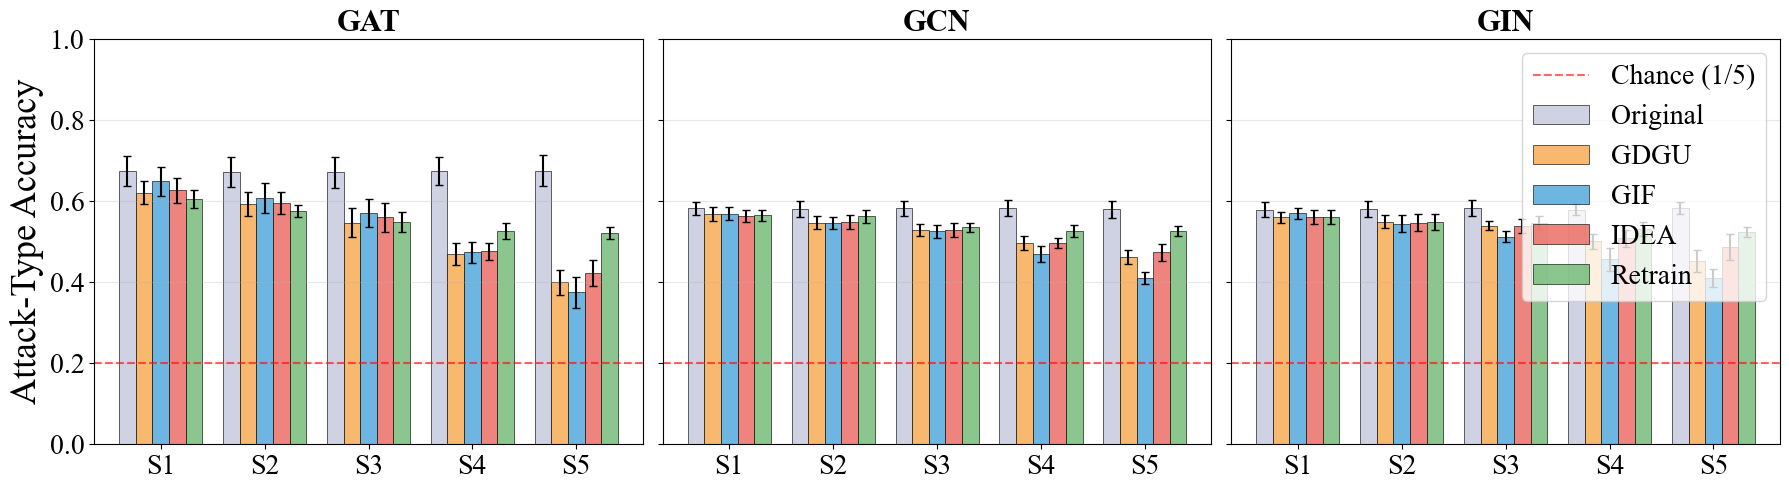

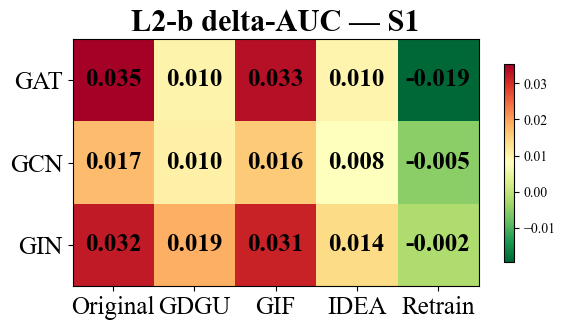

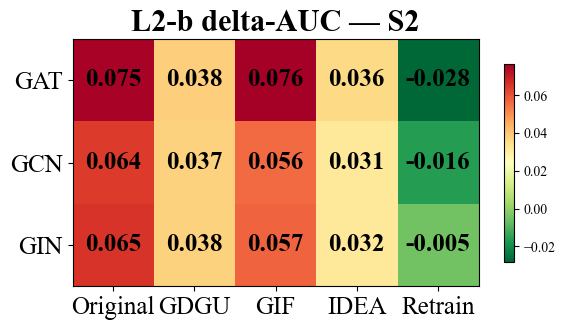

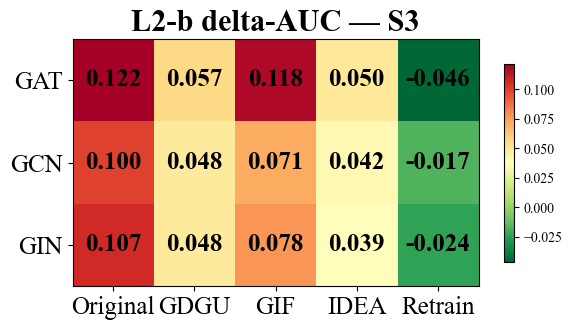

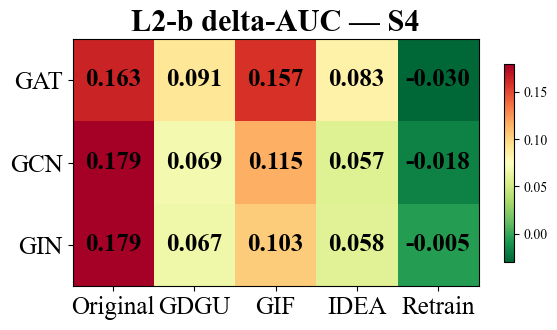

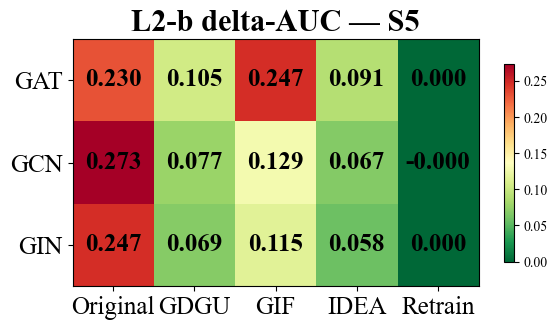

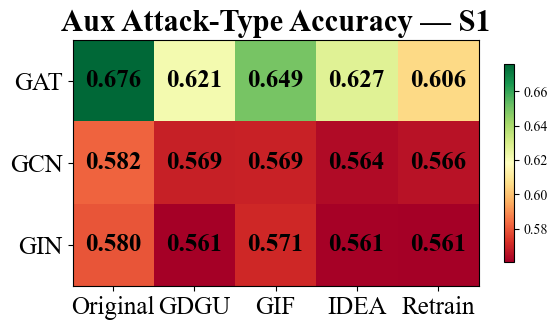

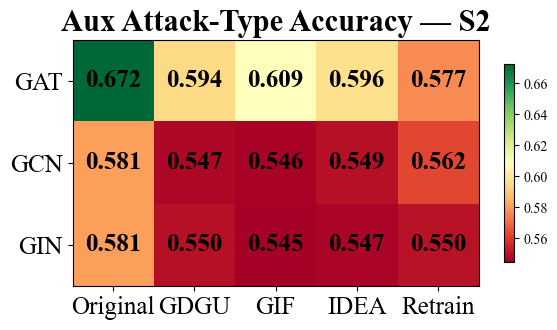

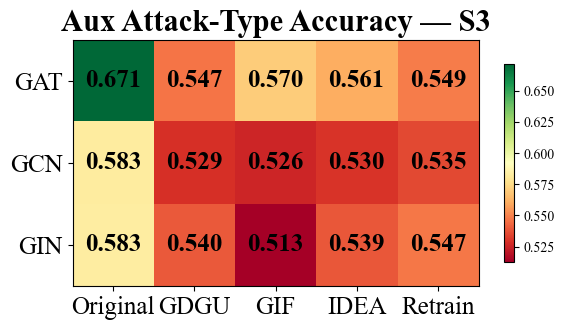

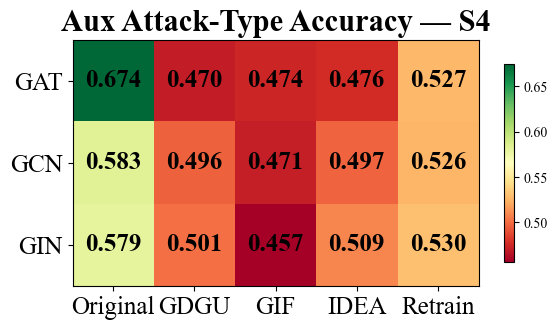

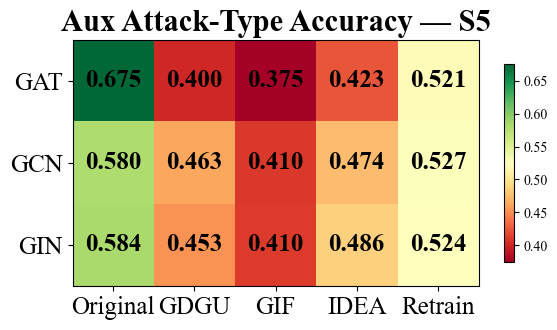


All V6.0 figures saved to /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-24_01/ (prefix: 123bus_)

Figures saved to: /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-24_01/


In [51]:
# Cell 3 — One-shot: generate all V6.0 figures
plot_all_v6(df, str(RESULTS_DIR), scenarios, backbones, bus_system=BUS_SYSTEM)
print(f'\nFigures saved to: {RESULTS_DIR}/')

## Individual plots (optional — for tweaking)

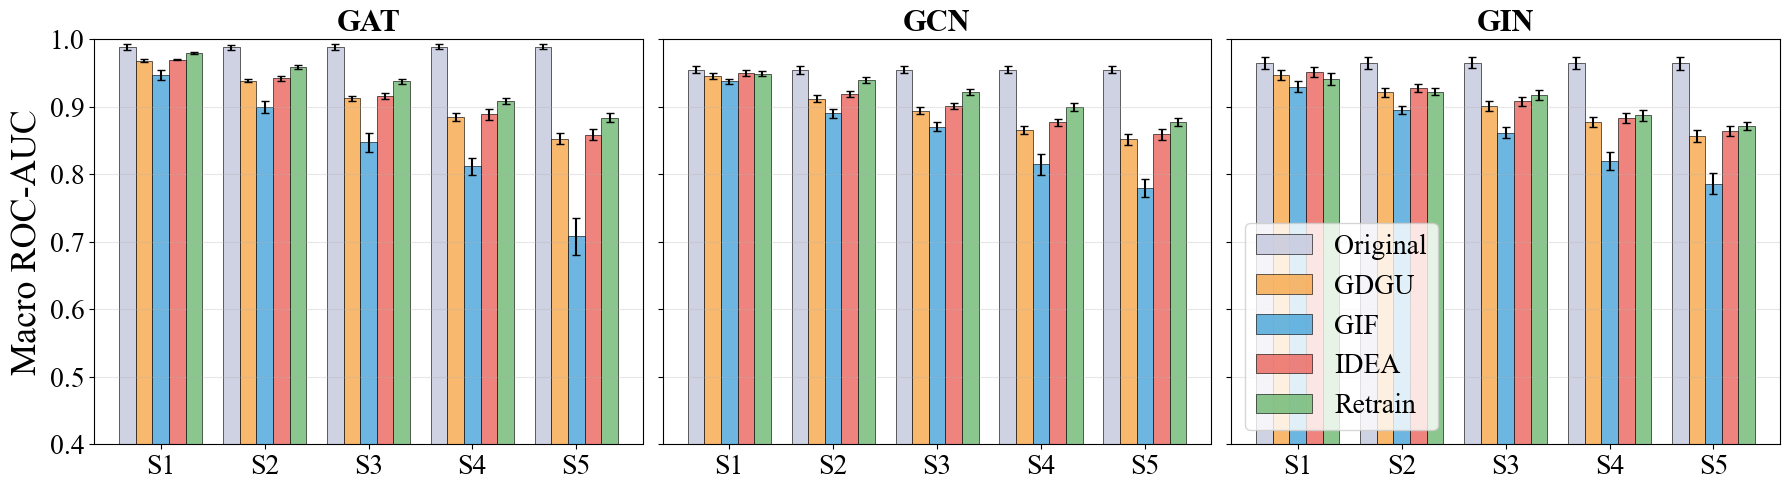

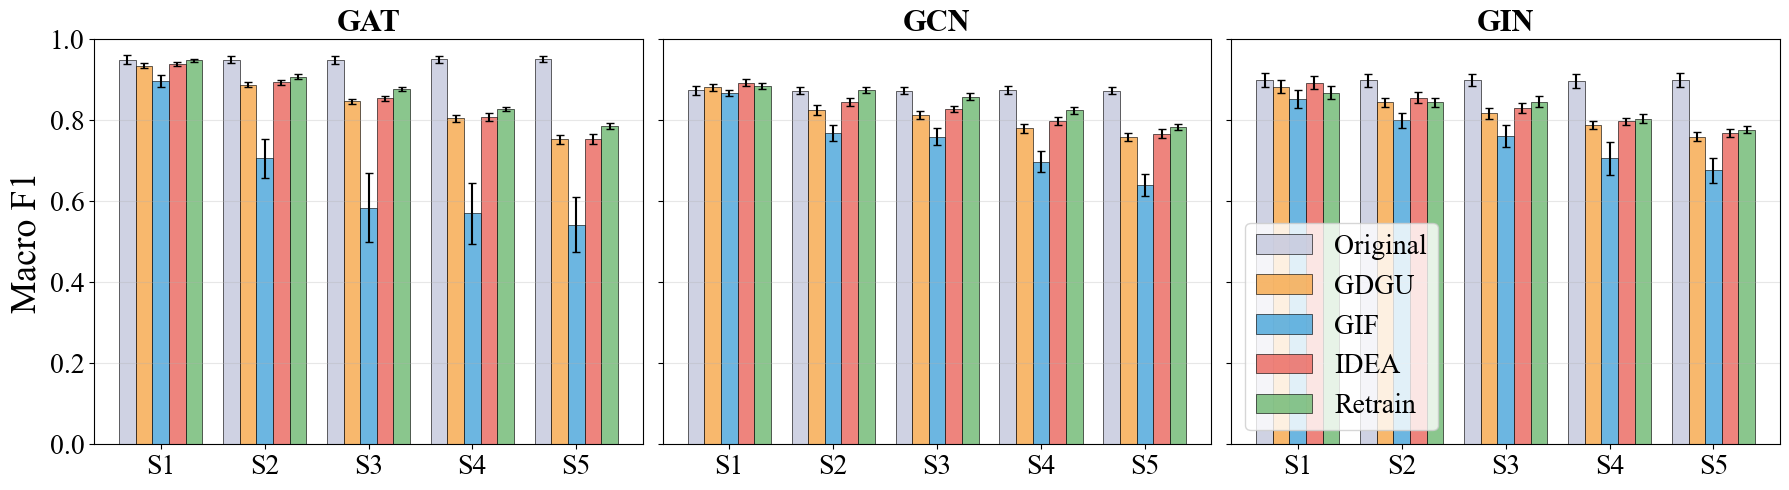

In [52]:
# Cell 4 — L1 utility: Macro ROC-AUC / Macro F1 / ExMatch
plot_metric_bars(df, 'Macro_ROC', 'Macro ROC-AUC', (0.4, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_MacroROC_comparison.pdf'),
                 scenarios, backbones)
plot_metric_bars(df, 'Macro_F1', 'Macro F1', (0.0, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_MacroF1_comparison.pdf'),
                 scenarios, backbones)

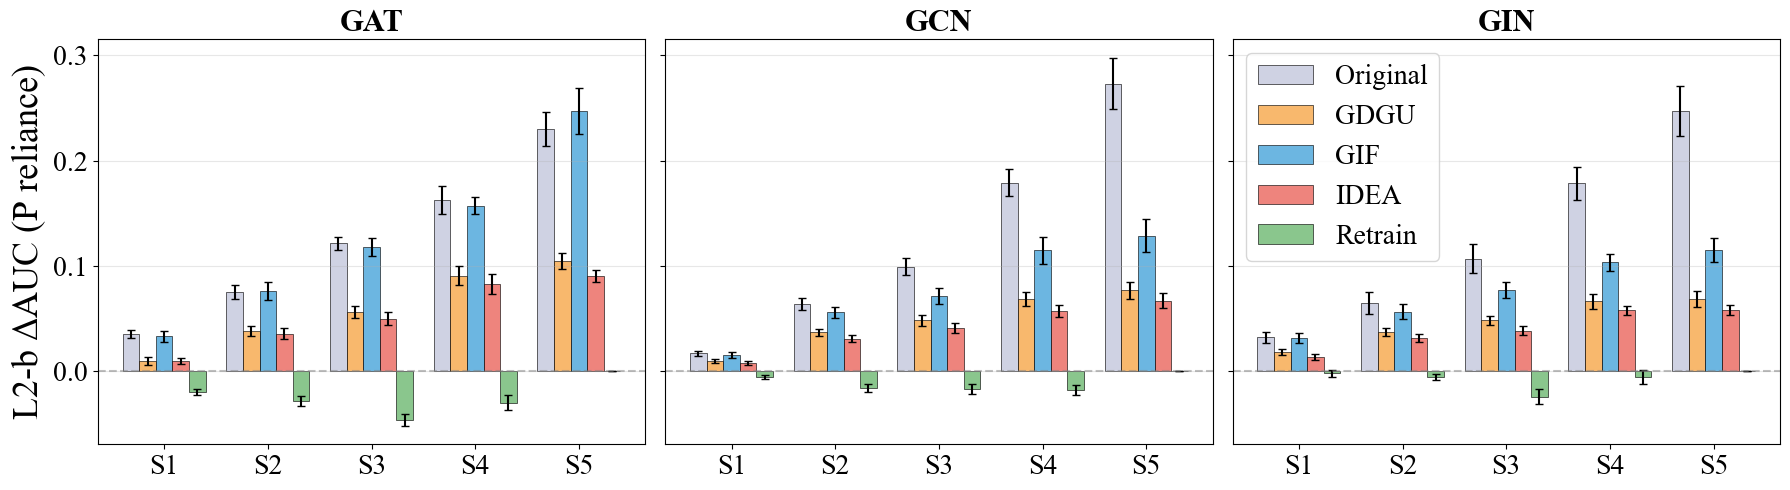

In [53]:
# Cell 5 — L2-b delta-AUC (PRIMARY privacy metric)
# Large positive → model relies heavily on P (not forgotten).
# Near 0 or negative → P has been effectively erased.
plot_l2b_delta_auc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_L2b_delta_auc.pdf'),
    scenarios, backbones)

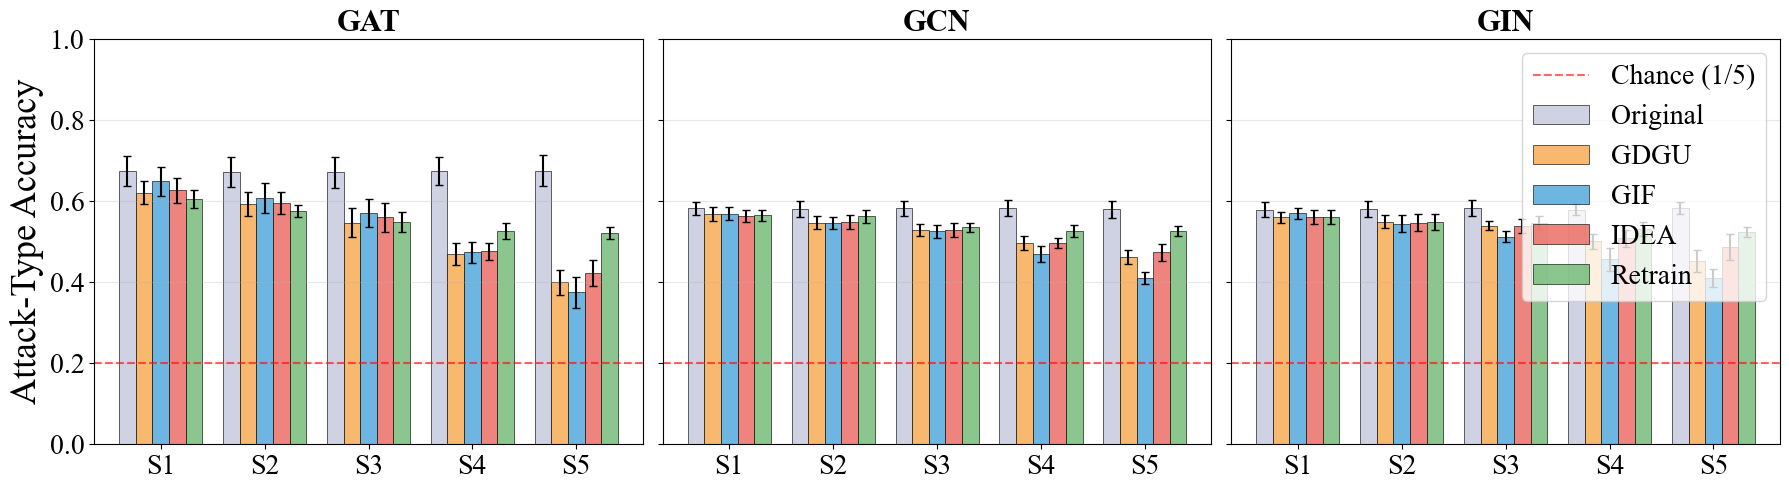

In [54]:
# Cell 6 — Aux attack-type accuracy (L2-e)
plot_aux_accuracy(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Aux_accuracy.pdf'),
    scenarios, backbones)

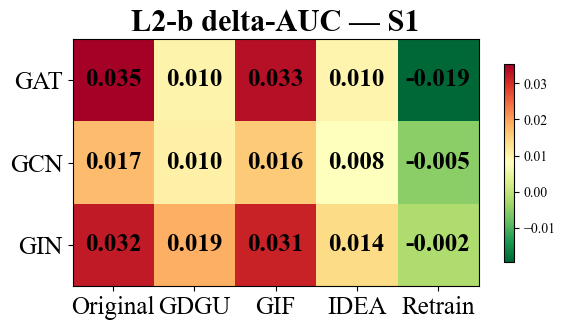

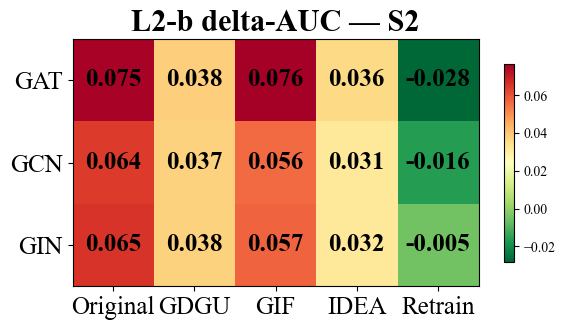

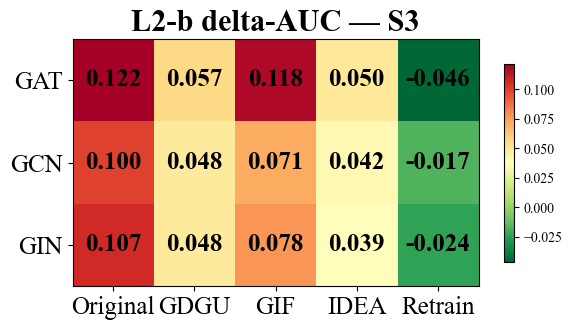

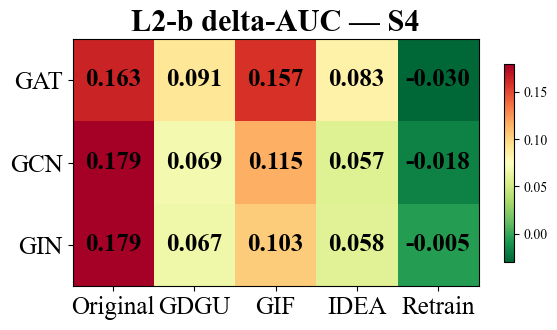

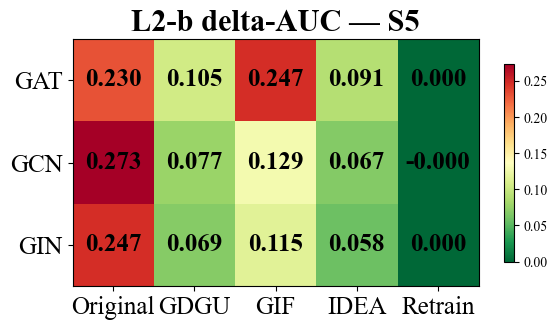

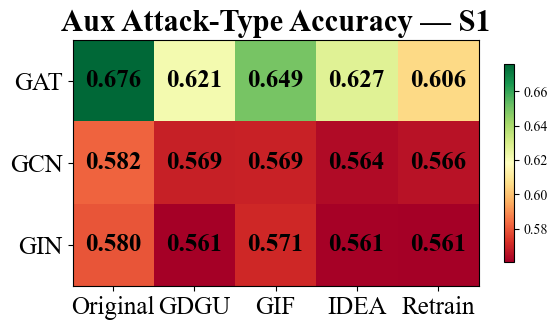

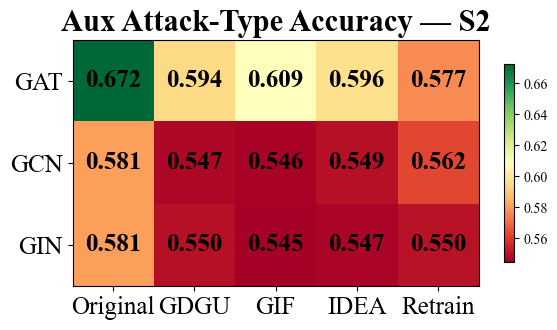

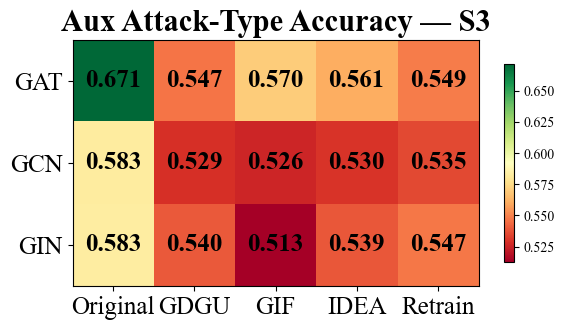

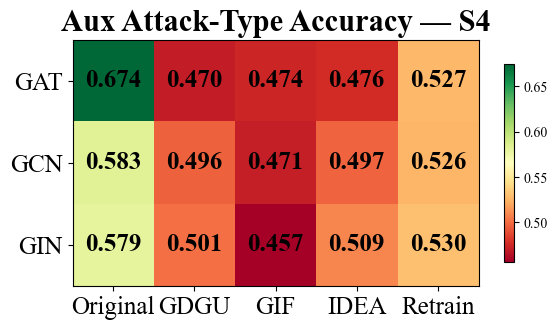

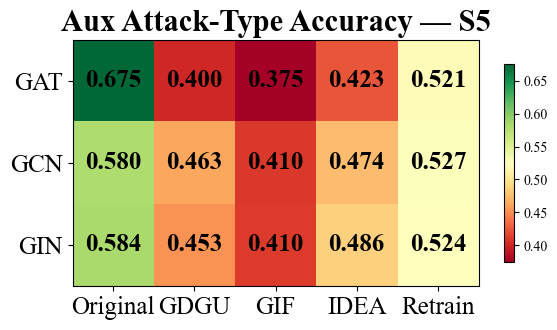

In [55]:
# Cell 7 — L2 heatmaps (method × backbone, one figure per scenario)
plot_l2_heatmap(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_L2b_heatmap.pdf'),
    scenarios, backbones,
    metric='L2b_delta_auc', title='L2-b delta-AUC')

plot_l2_heatmap(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Aux_heatmap.pdf'),
    scenarios, backbones,
    metric='Aux_Acc', title='Aux Attack-Type Accuracy')

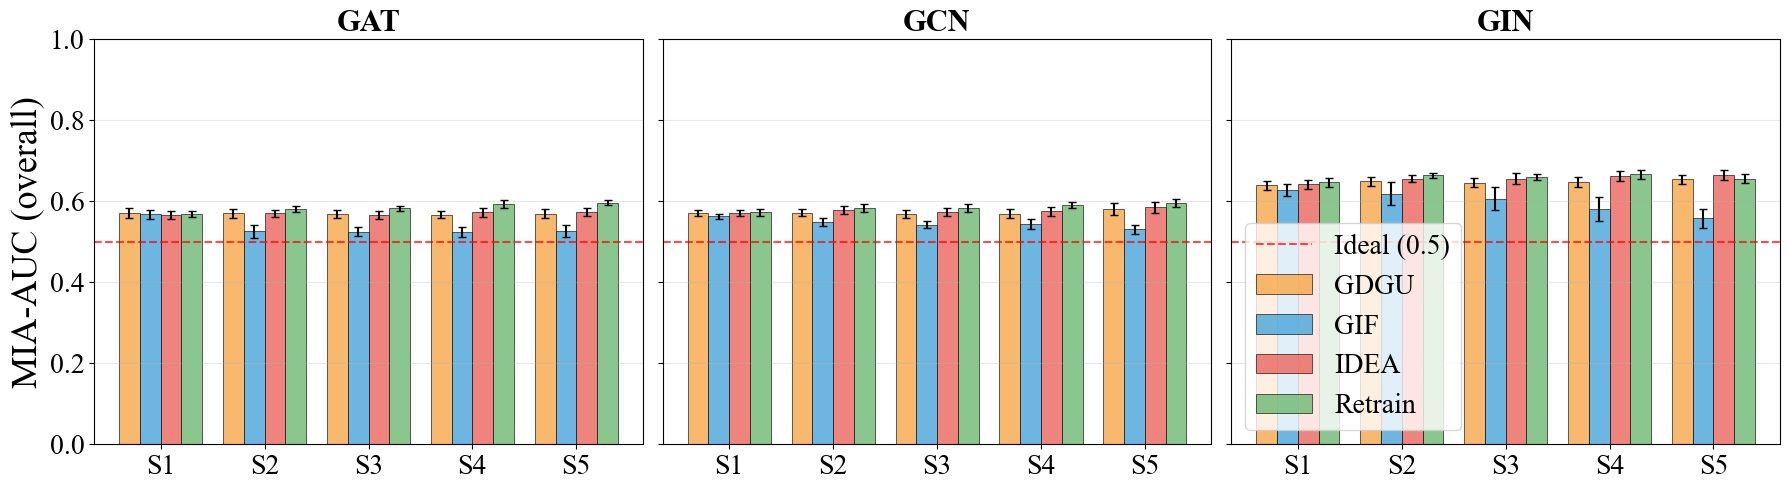

In [56]:
# Cell 8 — MIA (reference only, downgraded in V6.0)
plot_mia_auc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_MIA_comparison.pdf'),
    scenarios, backbones)

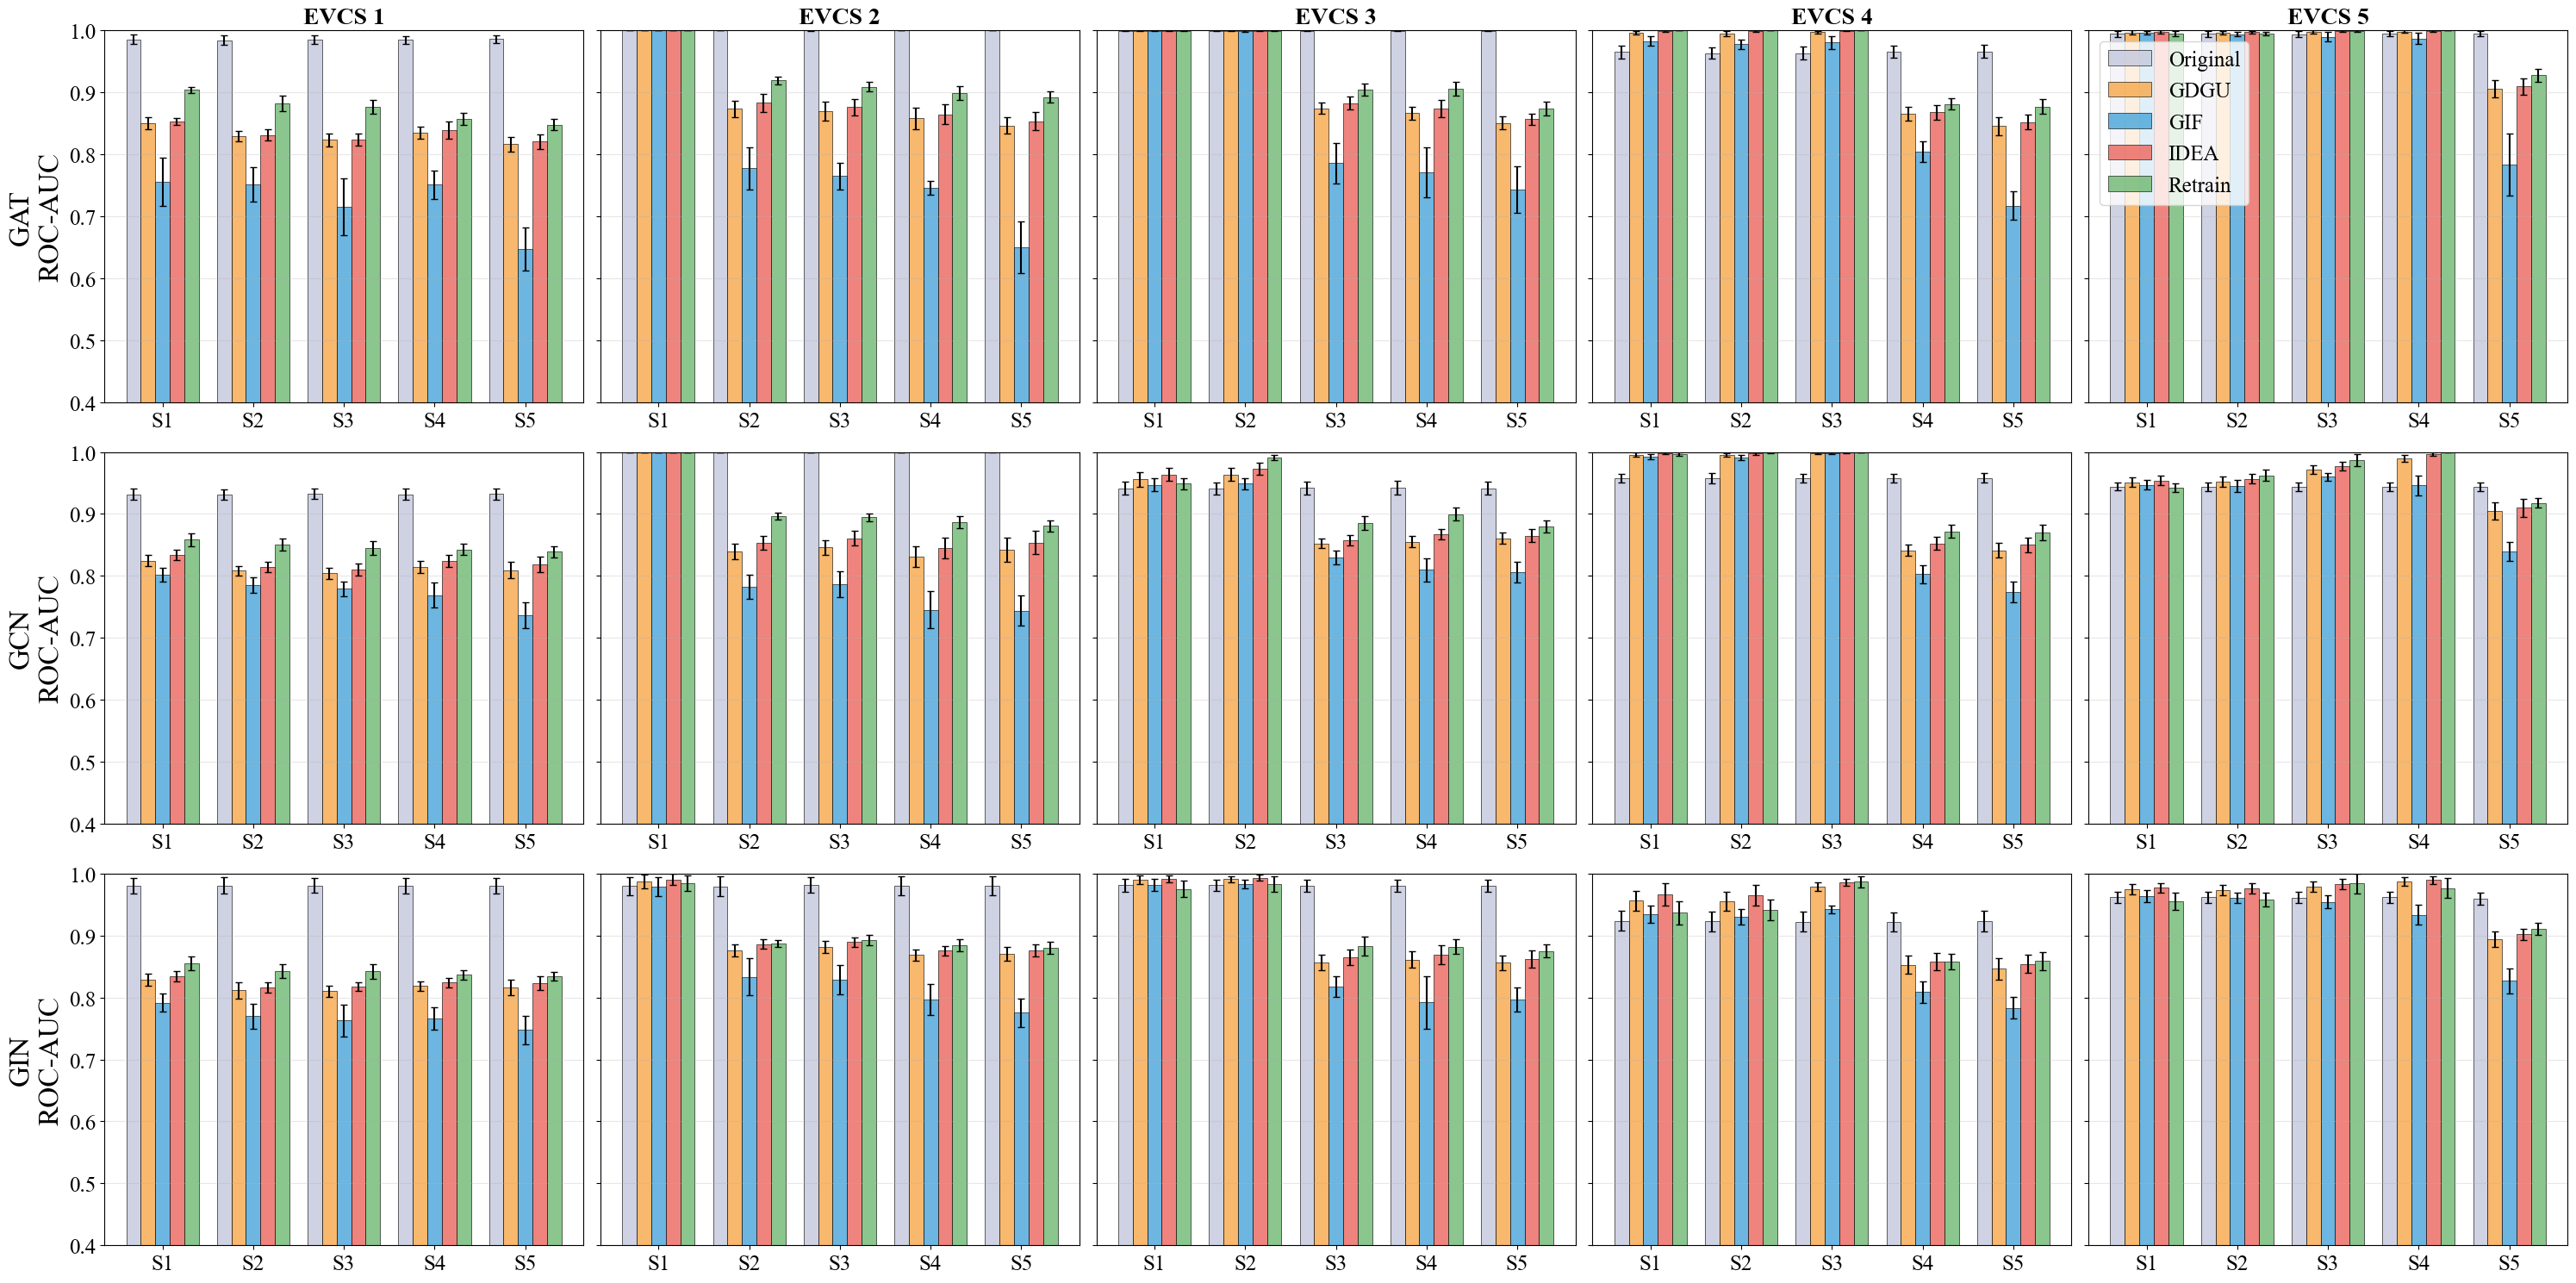

In [57]:
# Cell 9 — Per-EVCS ROC breakdown
plot_per_evcs_roc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_PerEVCS_ROC.pdf'),
    scenarios, backbones)

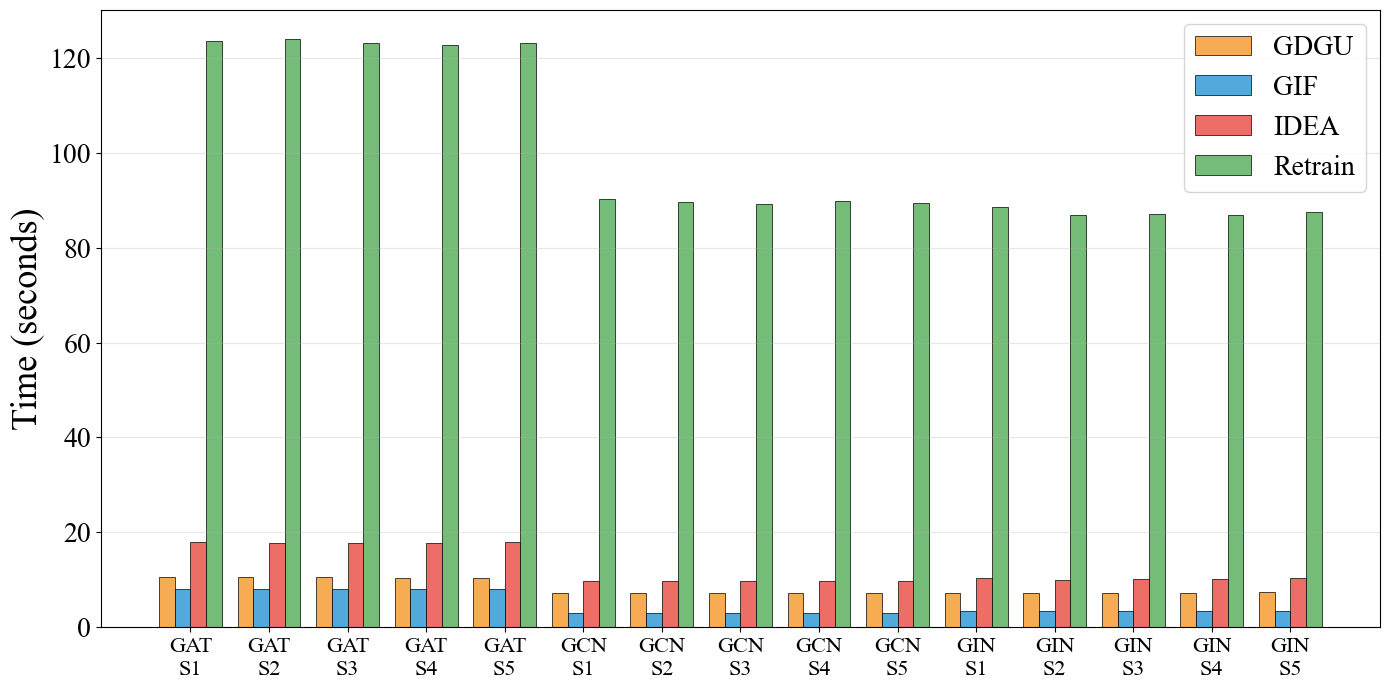

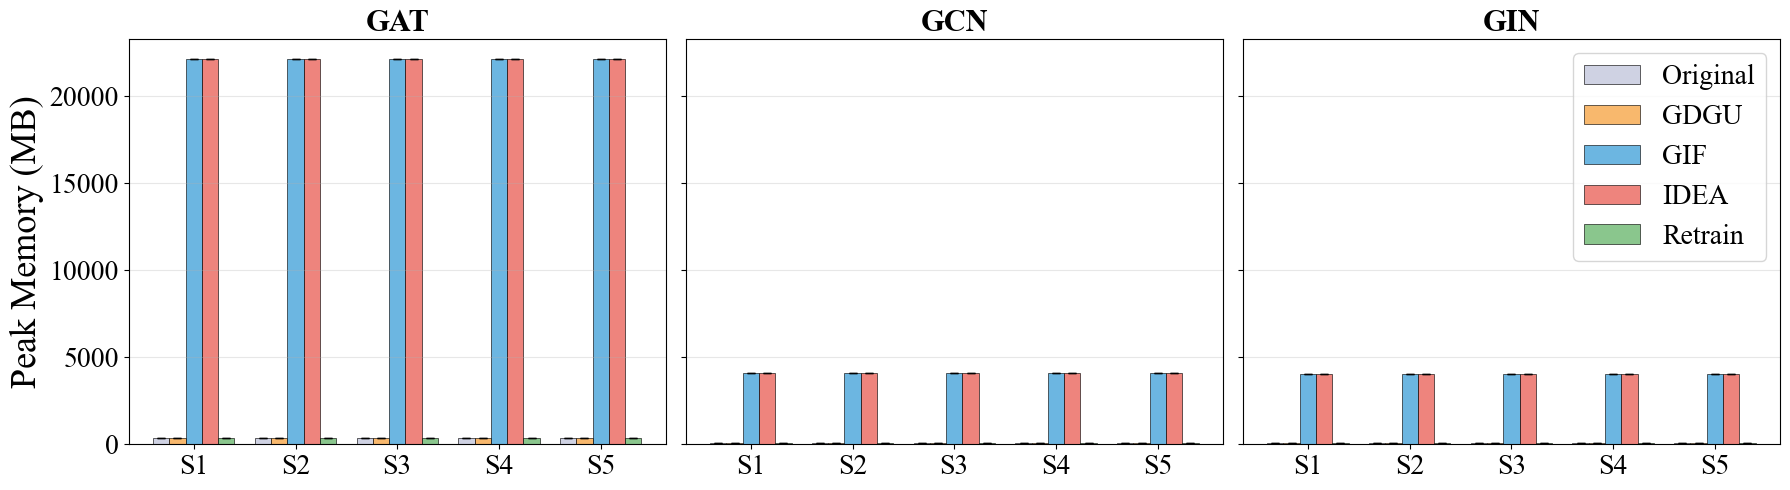

In [58]:
# Cell 10 — Efficiency: time & memory
plot_time_comparison(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Time.pdf'),
    scenarios, backbones)
plot_memory_usage(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Memory.pdf'),
    scenarios, backbones)

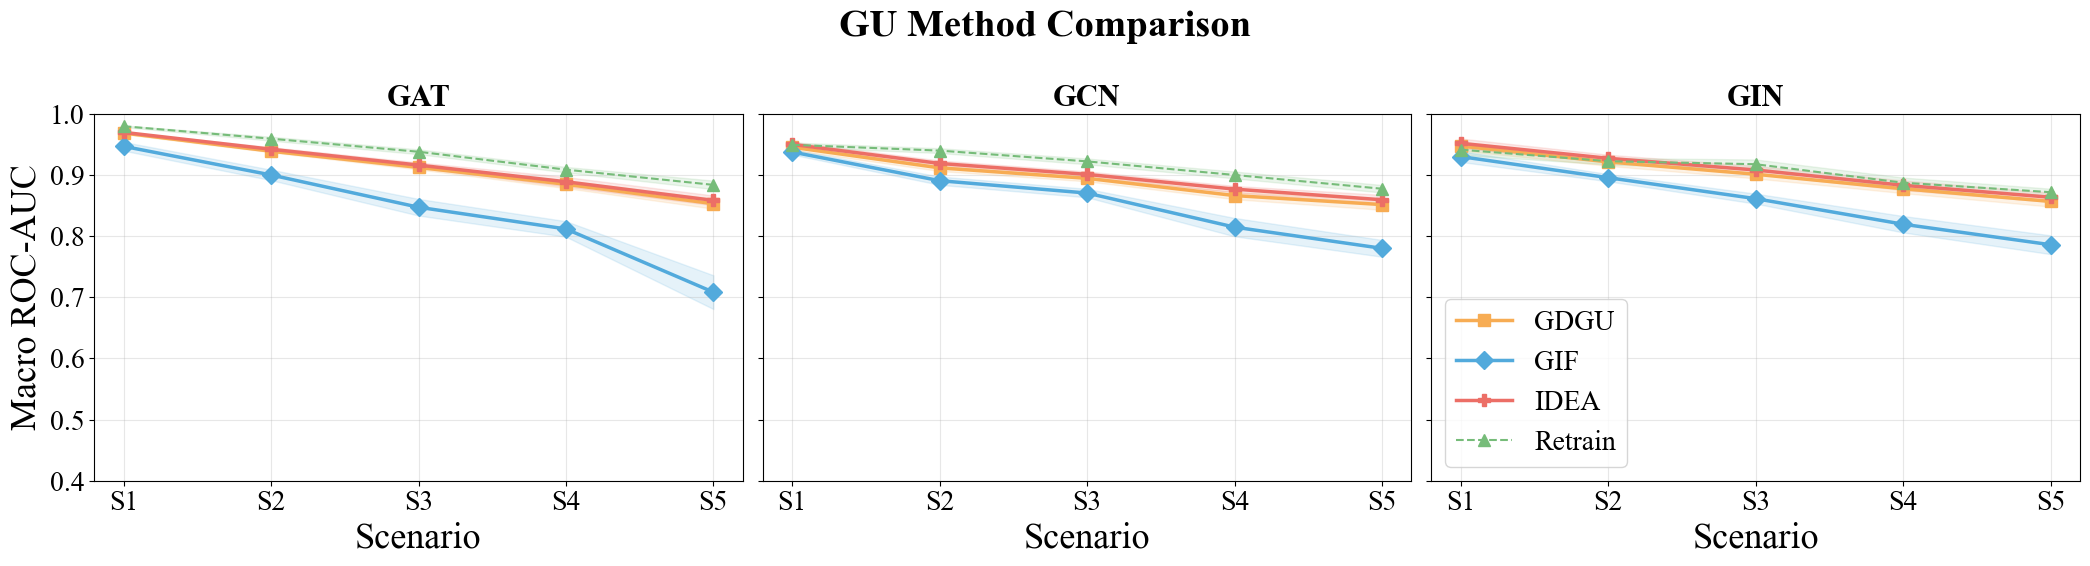

In [59]:
# Cell 11 — GU method comparison (F1 vs Time Pareto)
plot_gu_comparison(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_GU_comparison.pdf'),
    scenarios, backbones)

In [60]:
# Cell 12 — Summary tables
import pandas as pd

metrics = ['Macro_ROC', 'Macro_F1', 'ExMatch',
           'L2b_delta_auc', 'L2a_IG_mean', 'Aux_Acc',
           'MIA_forget', 'Time']
metrics = [m for m in metrics if m in df.columns]

summary = (df.groupby(['Backbone', 'Scenario', 'Method'])[metrics]
             .agg(['mean', 'std']).round(4))
display(summary)

# Per-method mean across all backbones and scenarios
overall = df.groupby('Method')[metrics].mean().round(4)
display(overall)

Macro_ROC         Macro_F1         ExMatch          \
                                mean     std     mean     std    mean     std   
Backbone Scenario Method                                                        
GAT      S1       GDGU        0.9686  0.0019   0.9351  0.0056  0.7163  0.0181   
                  GIF         0.9468  0.0071   0.8971  0.0157  0.6217  0.0299   
                  IDEA        0.9697  0.0011   0.9390  0.0047  0.7275  0.0138   
                  Original    0.9889  0.0042   0.9501  0.0104  0.8063  0.0420   
                  Retrain     0.9797  0.0012   0.9478  0.0030  0.7738  0.0111   
...                              ...     ...      ...     ...     ...     ...   
GIN      S5       GDGU        0.8568  0.0085   0.7599  0.0111  0.3877  0.0223   
                  GIF         0.7860  0.0154   0.6772  0.0310  0.3040  0.0263   
                  IDEA        0.8636  0.0075   0.7691  0.0098  0.3927  0.0110   
                  Original    0.9648  0.0095   0.8995  0.0177  0.6505  0.0438   
                  Retrain     0.8719  0.0057   0.7764  0.0086  0.3915  0.0121   

                           L2b_delta_auc         L2a_IG_mean         Aux_Acc  \
                                    mean     std        mean     std    mean   
Backbone Scenario Method                                                       
GAT      S1       GDGU            0.0101  0.0039      1.7000  0.2767  0.6215   
                  GIF             0.0333  0.0053      1.9641  0.3902  0.6495   
                  IDEA            0.0098  0.0030      1.6368  0.2505  0.6273   
                  Original        0.0353  0.0037      4.3872  0.6183  0.6755   
                  Retrain        -0.0193  0.0025      0.8856  0.1071  0.6057   
...                                  ...     ...         ...     ...     ...   
GIN      S5       GDGU            0.0686  0.0075     31.9998  6.8634  0.4532   
                  GIF             0.1153  0.0117     32.8527  6.0856  0.4105   
                  IDEA            0.0585  0.0049     29.7397  5.7027  0.4862   
                  Original        0.2473  0.0234     47.2207  7.3594  0.5835   
                  Retrain         0.0000  0.0000      0.0000  0.0000  0.5242   

                                   MIA_forget              Time          
                               std       mean     std      mean     std  
Backbone Scenario Method                                                 
GAT      S1       GDGU      0.0288     0.5465  0.0081   10.6087  0.2829  
                  GIF       0.0355     0.5407  0.0112    8.1454  0.0051  
                  IDEA      0.0313     0.5434  0.0075   17.9152  0.2934  
                  Original  0.0370        NaN     NaN  123.6663  1.9649  
                  Retrain   0.0216     0.5469  0.0111  123.6164  0.8258  
...                            ...        ...     ...       ...     ...  
GIN      S5       GDGU      0.0267     0.6539  0.0120    7.4006  0.6254  
                  GIF       0.0231     0.5580  0.0239    3.4971  0.0938  
                  IDEA      0.0320     0.6649  0.0121   10.4690  0.9153  
                  Original  0.0158        NaN     NaN   88.0654  5.7266  
                  Retrain   0.0131     0.6561  0.0119   87.4188  4.6804  

[75 rows x 16 columns]

,Macro_ROC,Macro_F1,ExMatch,L2b_delta_auc,L2a_IG_mean,Aux_Acc,MIA_forget,Time
Method,,,,,,,,
GDGU,0.9021,0.8255,0.4792,0.0522,17.4936,0.5228,0.5782,8.3643
GIF,0.8533,0.7220,0.3677,0.0936,18.9440,0.5130,0.5409,4.8639
IDEA,0.9077,0.8350,0.4947,0.0451,16.6400,0.5294,0.5839,12.6019
Original,0.9696,0.9077,0.6765,0.1260,23.9913,0.6122,NaN,100.5455
Retrain,0.9200,0.8473,0.5197,-0.0143,4.2388,0.5472,0.5915,100.1147
